# Canadian Vehicle Fuel Consumption Analysis

Complete local test notebook for the full project pipeline.

## 0. Environment and imports

This section verifies that the project modules can be imported correctly.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    DATA_PATH,
    FIGURES_DIR,
    TABLES_DIR,
    TARGET_COLUMN,
)
from src.data_loader import load_dataset
from src.data_quality import evaluate_data_quality, quality_summary_table
from src.feature_engineering import (
    clean_and_engineer_features,
    extract_speed_number,
    extract_transmission_type,
    infer_drivetrain,
    simplify_vehicle_class,
)
from src.statistical_analysis import run_default_statistical_tests
from src.visualization import generate_all_figures

print(f"Project root: {PROJECT_ROOT}")
print("All imports completed successfully.")


C:\Users\Trump\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Project root: C:\Users\Trump\OneDrive - USherbrooke\Documents\Projets_github\canada-fuel-consumption-analysis
All imports completed successfully.


## 1. Verify the dataset path

In [2]:
print(f"Expected dataset path: {DATA_PATH}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Place the CSV file at:\n"
        f"{DATA_PATH}"
    )

print("Dataset file found.")


Expected dataset path: C:\Users\Trump\OneDrive - USherbrooke\Documents\Projets_github\canada-fuel-consumption-analysis\data\raw\my2015-2024-fuel-consumption-ratings.csv
Dataset file found.


## 2. Load the dataset

In [3]:
raw_data = load_dataset(DATA_PATH)

print(f"Rows loaded   : {raw_data.shape[0]}")
print(f"Columns loaded: {raw_data.shape[1]}")

raw_data.head()


Rows loaded   : 10058
Columns loaded: 15


,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,34,191,NaN,NaN
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,30,214,NaN,NaN
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,46,140,NaN,NaN
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,NaN,NaN
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,NaN,NaN


## 3. Inspect columns and missing values

In [4]:
column_summary = pd.DataFrame(
    {
        "dtype": raw_data.dtypes.astype(str),
        "missing_values": raw_data.isna().sum(),
        "unique_values": raw_data.nunique(),
    }
)

column_summary


,dtype,missing_values,unique_values
Model year,int64,0,10
Make,str,0,42
Model,str,0,2079
Vehicle class,str,0,15
Engine size (L),float64,0,50
Cylinders,int64,0,8
Transmission,str,0,28
Fuel type,str,0,5
City (L/100 km),float64,0,209
Highway (L/100 km),float64,0,142


## 4. Evaluate data quality

In [5]:
quality_results = evaluate_data_quality(raw_data)
quality_summary = quality_summary_table(quality_results)

print(
    f"Overall completeness: "
    f"{quality_results['overall_completeness']:.2%}"
)
print(
    f"Overall quality score: "
    f"{quality_results['overall_quality_score']:.2f}/10"
)

quality_summary


Overall completeness: 97.77%
Overall quality score: 9.96/10


,metric,value
0,overall_completeness,0.977716
1,overall_quality_score_out_of_10,9.957579
2,valid_model_year,1.000000
3,valid_engine_size,1.000000
4,valid_cylinders,1.000000
5,valid_consumption,1.000000
6,highway_combined_city_consistency,0.974548
7,valid_fuel_type,1.000000


## 5. Clean and engineer features

In [6]:
cleaned_data = clean_and_engineer_features(raw_data)

print(f"Rows before cleaning: {raw_data.shape[0]}")
print(f"Rows after cleaning : {cleaned_data.shape[0]}")
print(f"Columns after feature engineering: {cleaned_data.shape[1]}")

cleaned_data.head()


Rows before cleaning: 10058
Rows after cleaning : 10058
Columns after feature engineering: 17


,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Manufacturer country,Drivetrain inferred,Flexible fuel inferred,Vehicle class simplified,Transmission type,Speed count
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,Japan,Unknown / Other,False,Compact,Automatic with select shift,5
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,Japan,Unknown / Other,False,Compact,Manual,6
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,Japan,Unknown / Other,False,Compact,Continuously variable,7
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,Japan,AWD,False,SUV,Automatic with select shift,6
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,Japan,AWD,False,SUV,Automatic with select shift,6


## 6. Verify engineered features

In [7]:
engineered_columns = [
    "Manufacturer country",
    "Drivetrain inferred",
    "Flexible fuel inferred",
    "Vehicle class simplified",
    "Transmission type",
    "Speed count",
]

missing_engineered_columns = [
    column
    for column in engineered_columns
    if column not in cleaned_data.columns
]

if missing_engineered_columns:
    raise AssertionError(
        f"Missing engineered columns: {missing_engineered_columns}"
    )

print("All engineered columns are present.")
cleaned_data[engineered_columns].head()


All engineered columns are present.


,Manufacturer country,Drivetrain inferred,Flexible fuel inferred,Vehicle class simplified,Transmission type,Speed count
0,Japan,Unknown / Other,False,Compact,Automatic with select shift,5
1,Japan,Unknown / Other,False,Compact,Manual,6
2,Japan,Unknown / Other,False,Compact,Continuously variable,7
3,Japan,AWD,False,SUV,Automatic with select shift,6
4,Japan,AWD,False,SUV,Automatic with select shift,6


## 7. Run feature-engineering smoke tests

In [8]:
assert infer_drivetrain("Example AWD") == "AWD"
assert infer_drivetrain("Example 4WD") == "4WD / 4x4"
assert infer_drivetrain("Example FWD") == "FWD"
assert infer_drivetrain("Example") == "Unknown / Other"

assert extract_transmission_type("AS8") == "Automatic with select shift"
assert extract_speed_number("AS8") == 8
assert simplify_vehicle_class("SUV: Small") == "SUV"
assert simplify_vehicle_class("Pickup truck") == "Truck"

print("Feature-engineering smoke tests passed.")


Feature-engineering smoke tests passed.


## 8. Run corrected statistical tests

In [9]:
pairwise_tests, global_tests = run_default_statistical_tests(
    cleaned_data,
    TARGET_COLUMN,
)

print("Pairwise Welch tests:")
display(pairwise_tests)

print("Global Kruskal-Wallis tests:")
display(global_tests)


Pairwise Welch tests:


,group_column,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_difference_a_minus_b,ci_95_low,ci_95_high,welch_t,p_value,hedges_g
0,Drivetrain inferred,AWD,4WD / 4x4,1687,1366,10.342561,12.897145,-2.554584,-2.718672,-2.390496,-30.528270,4.098275e-174,-1.143394
1,Fuel type,D,X,236,4754,9.344492,10.053912,-0.709421,-0.906289,-0.512553,-7.090545,9.113577e-12,-0.291084
2,Manufacturer country,Japan,United States,2108,3407,9.238283,12.022747,-2.784465,-2.917515,-2.651415,-41.027751,0.000000e+00,-1.083780


Global Kruskal-Wallis tests:


,group_column,group_count,groups,sample_size,kruskal_h,p_value,epsilon_squared
0,Drivetrain inferred,2,"4WD / 4x4, AWD",3053,749.761272,4.521781e-165,0.245415
1,Fuel type,4,"D, E, X, Z",10057,1561.253563,0.000000e+00,0.155004
2,Manufacturer country,7,"Germany, Italy, Japan, South Korea, Sweden, Un...",10058,1938.987303,0.000000e+00,0.192318


## 9. Save result tables

In [10]:
TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

quality_table_path = TABLES_DIR / "data_quality_summary.csv"
pairwise_table_path = TABLES_DIR / "pairwise_tests.csv"
global_table_path = TABLES_DIR / "global_group_tests.csv"

quality_summary.to_csv(
    quality_table_path,
    index=False,
)

pairwise_tests.to_csv(
    pairwise_table_path,
    index=False,
)

global_tests.to_csv(
    global_table_path,
    index=False,
)

print(f"Saved: {quality_table_path}")
print(f"Saved: {pairwise_table_path}")
print(f"Saved: {global_table_path}")


Saved: C:\Users\Trump\OneDrive - USherbrooke\Documents\Projets_github\canada-fuel-consumption-analysis\results\tables\data_quality_summary.csv
Saved: C:\Users\Trump\OneDrive - USherbrooke\Documents\Projets_github\canada-fuel-consumption-analysis\results\tables\pairwise_tests.csv
Saved: C:\Users\Trump\OneDrive - USherbrooke\Documents\Projets_github\canada-fuel-consumption-analysis\results\tables\global_group_tests.csv


## 10. Generate all figures

In [11]:
generate_all_figures(
    cleaned_data,
    FIGURES_DIR,
)

print(f"Figures generated in: {FIGURES_DIR}")


Figures generated in: C:\Users\Trump\OneDrive - USherbrooke\Documents\Projets_github\canada-fuel-consumption-analysis\results\figures


## 11. Display all generated figures


consumption_distribution.png


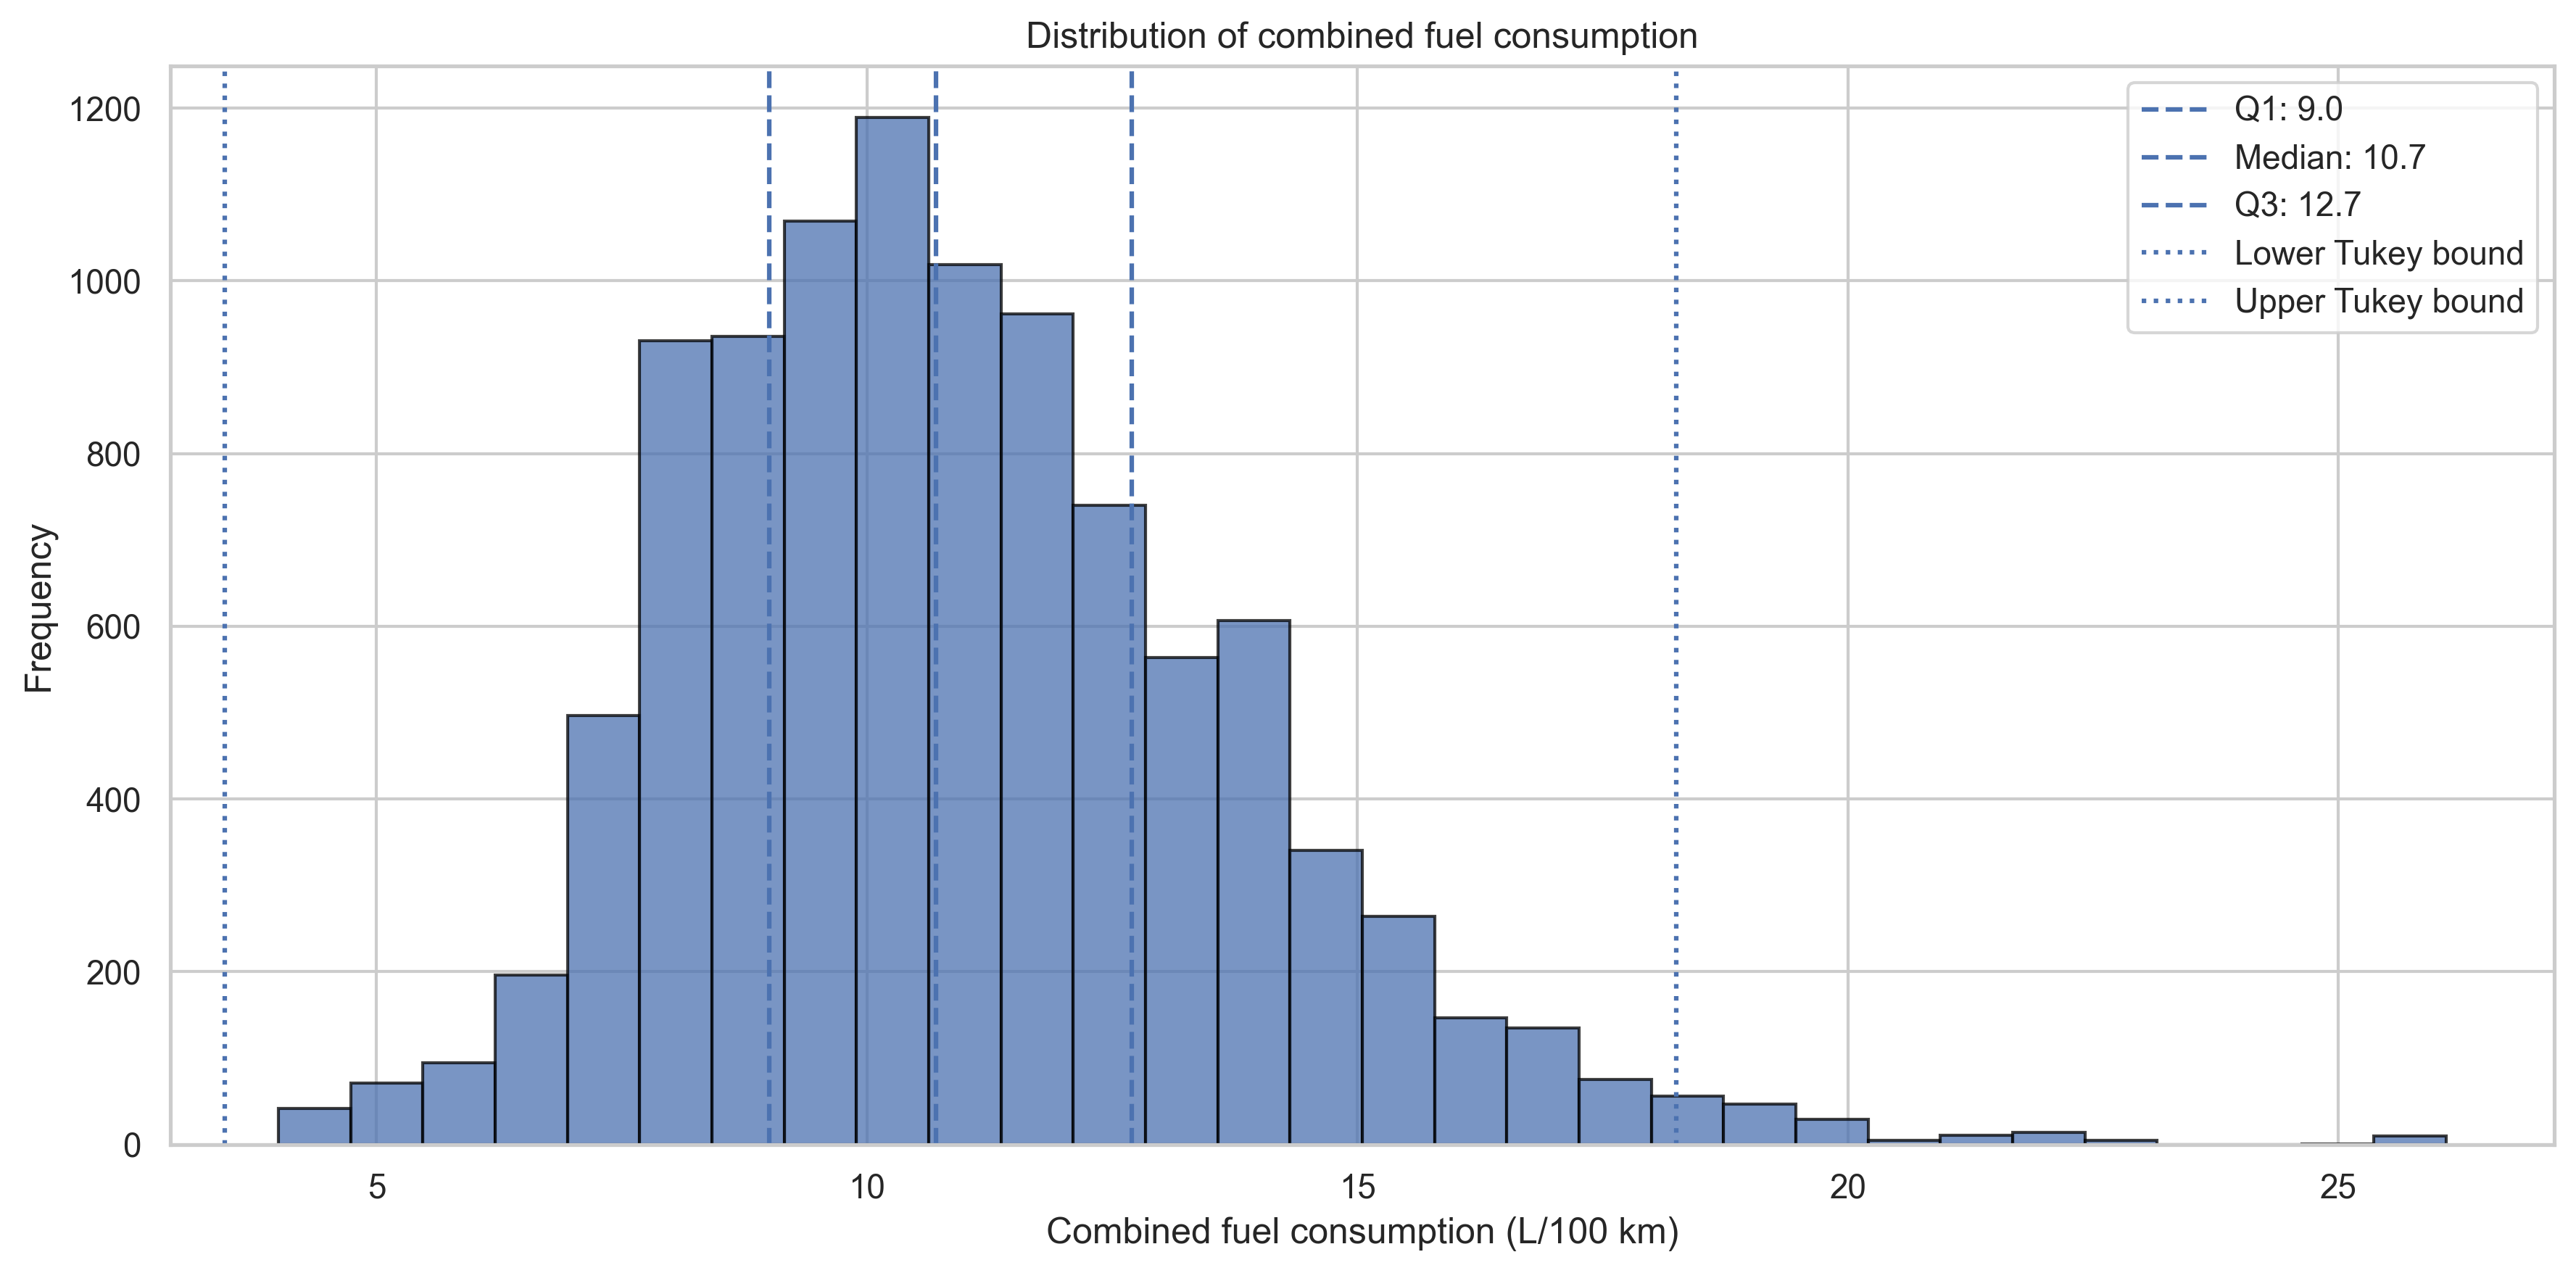


consumption_by_fuel.png


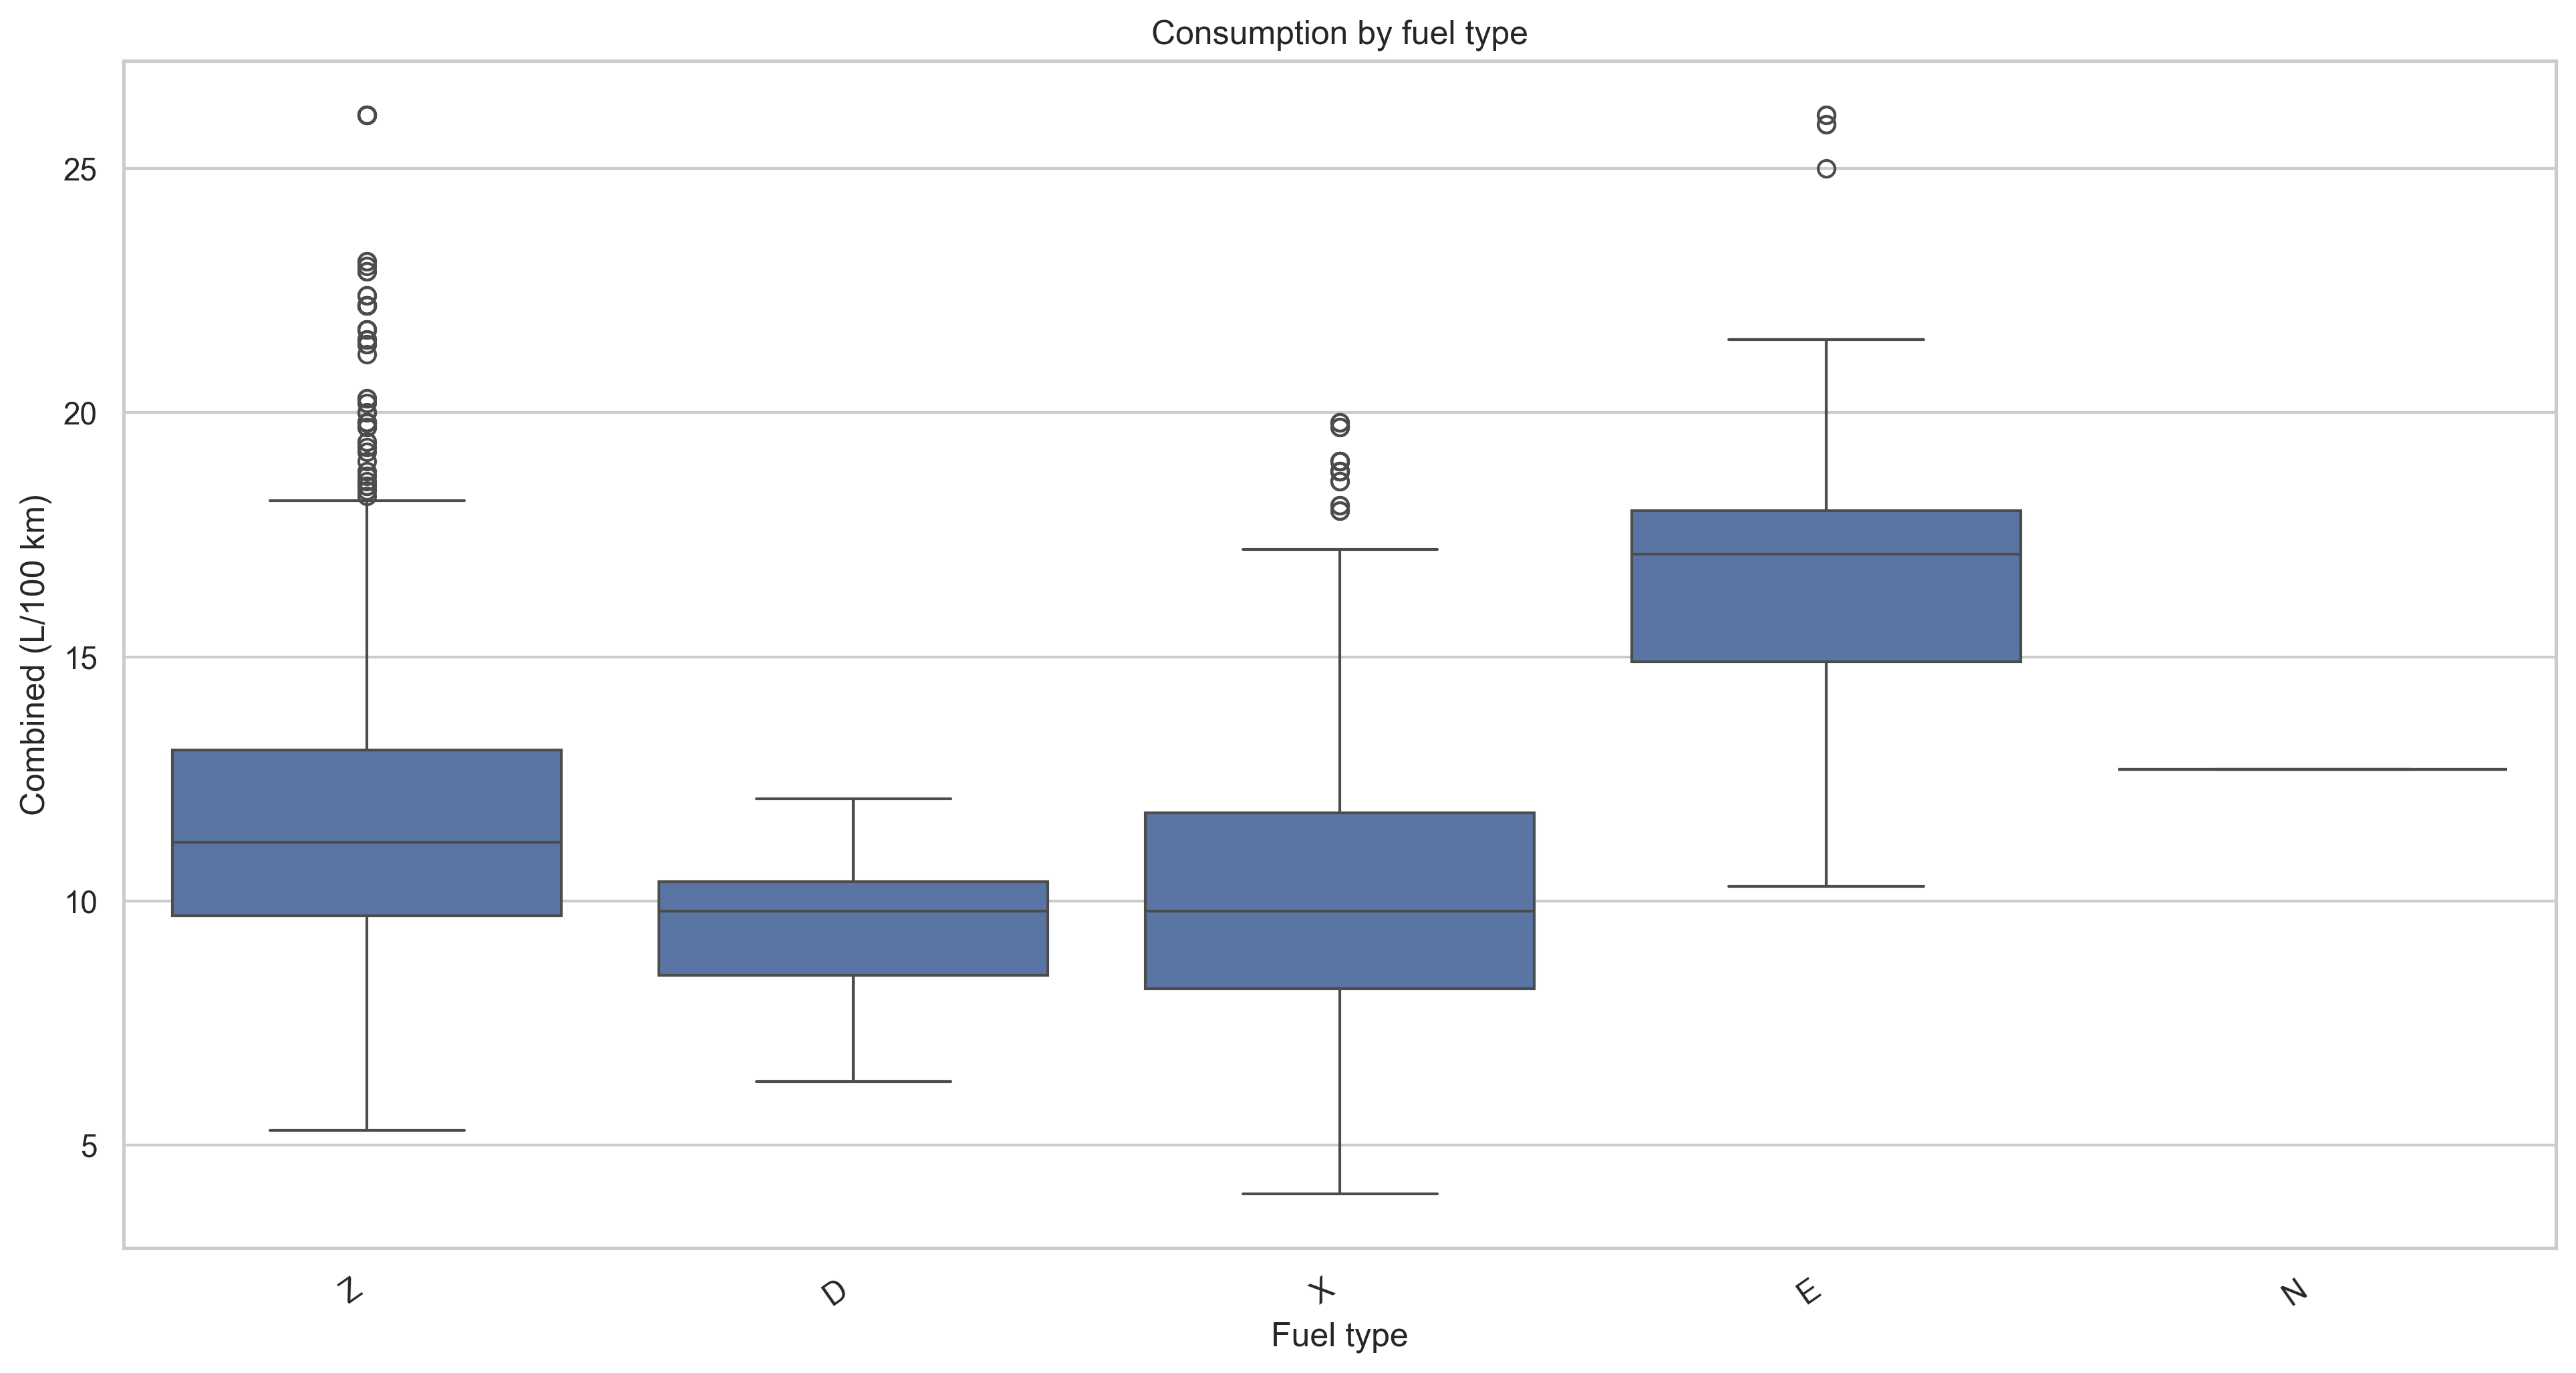


numeric_correlation_matrix.png


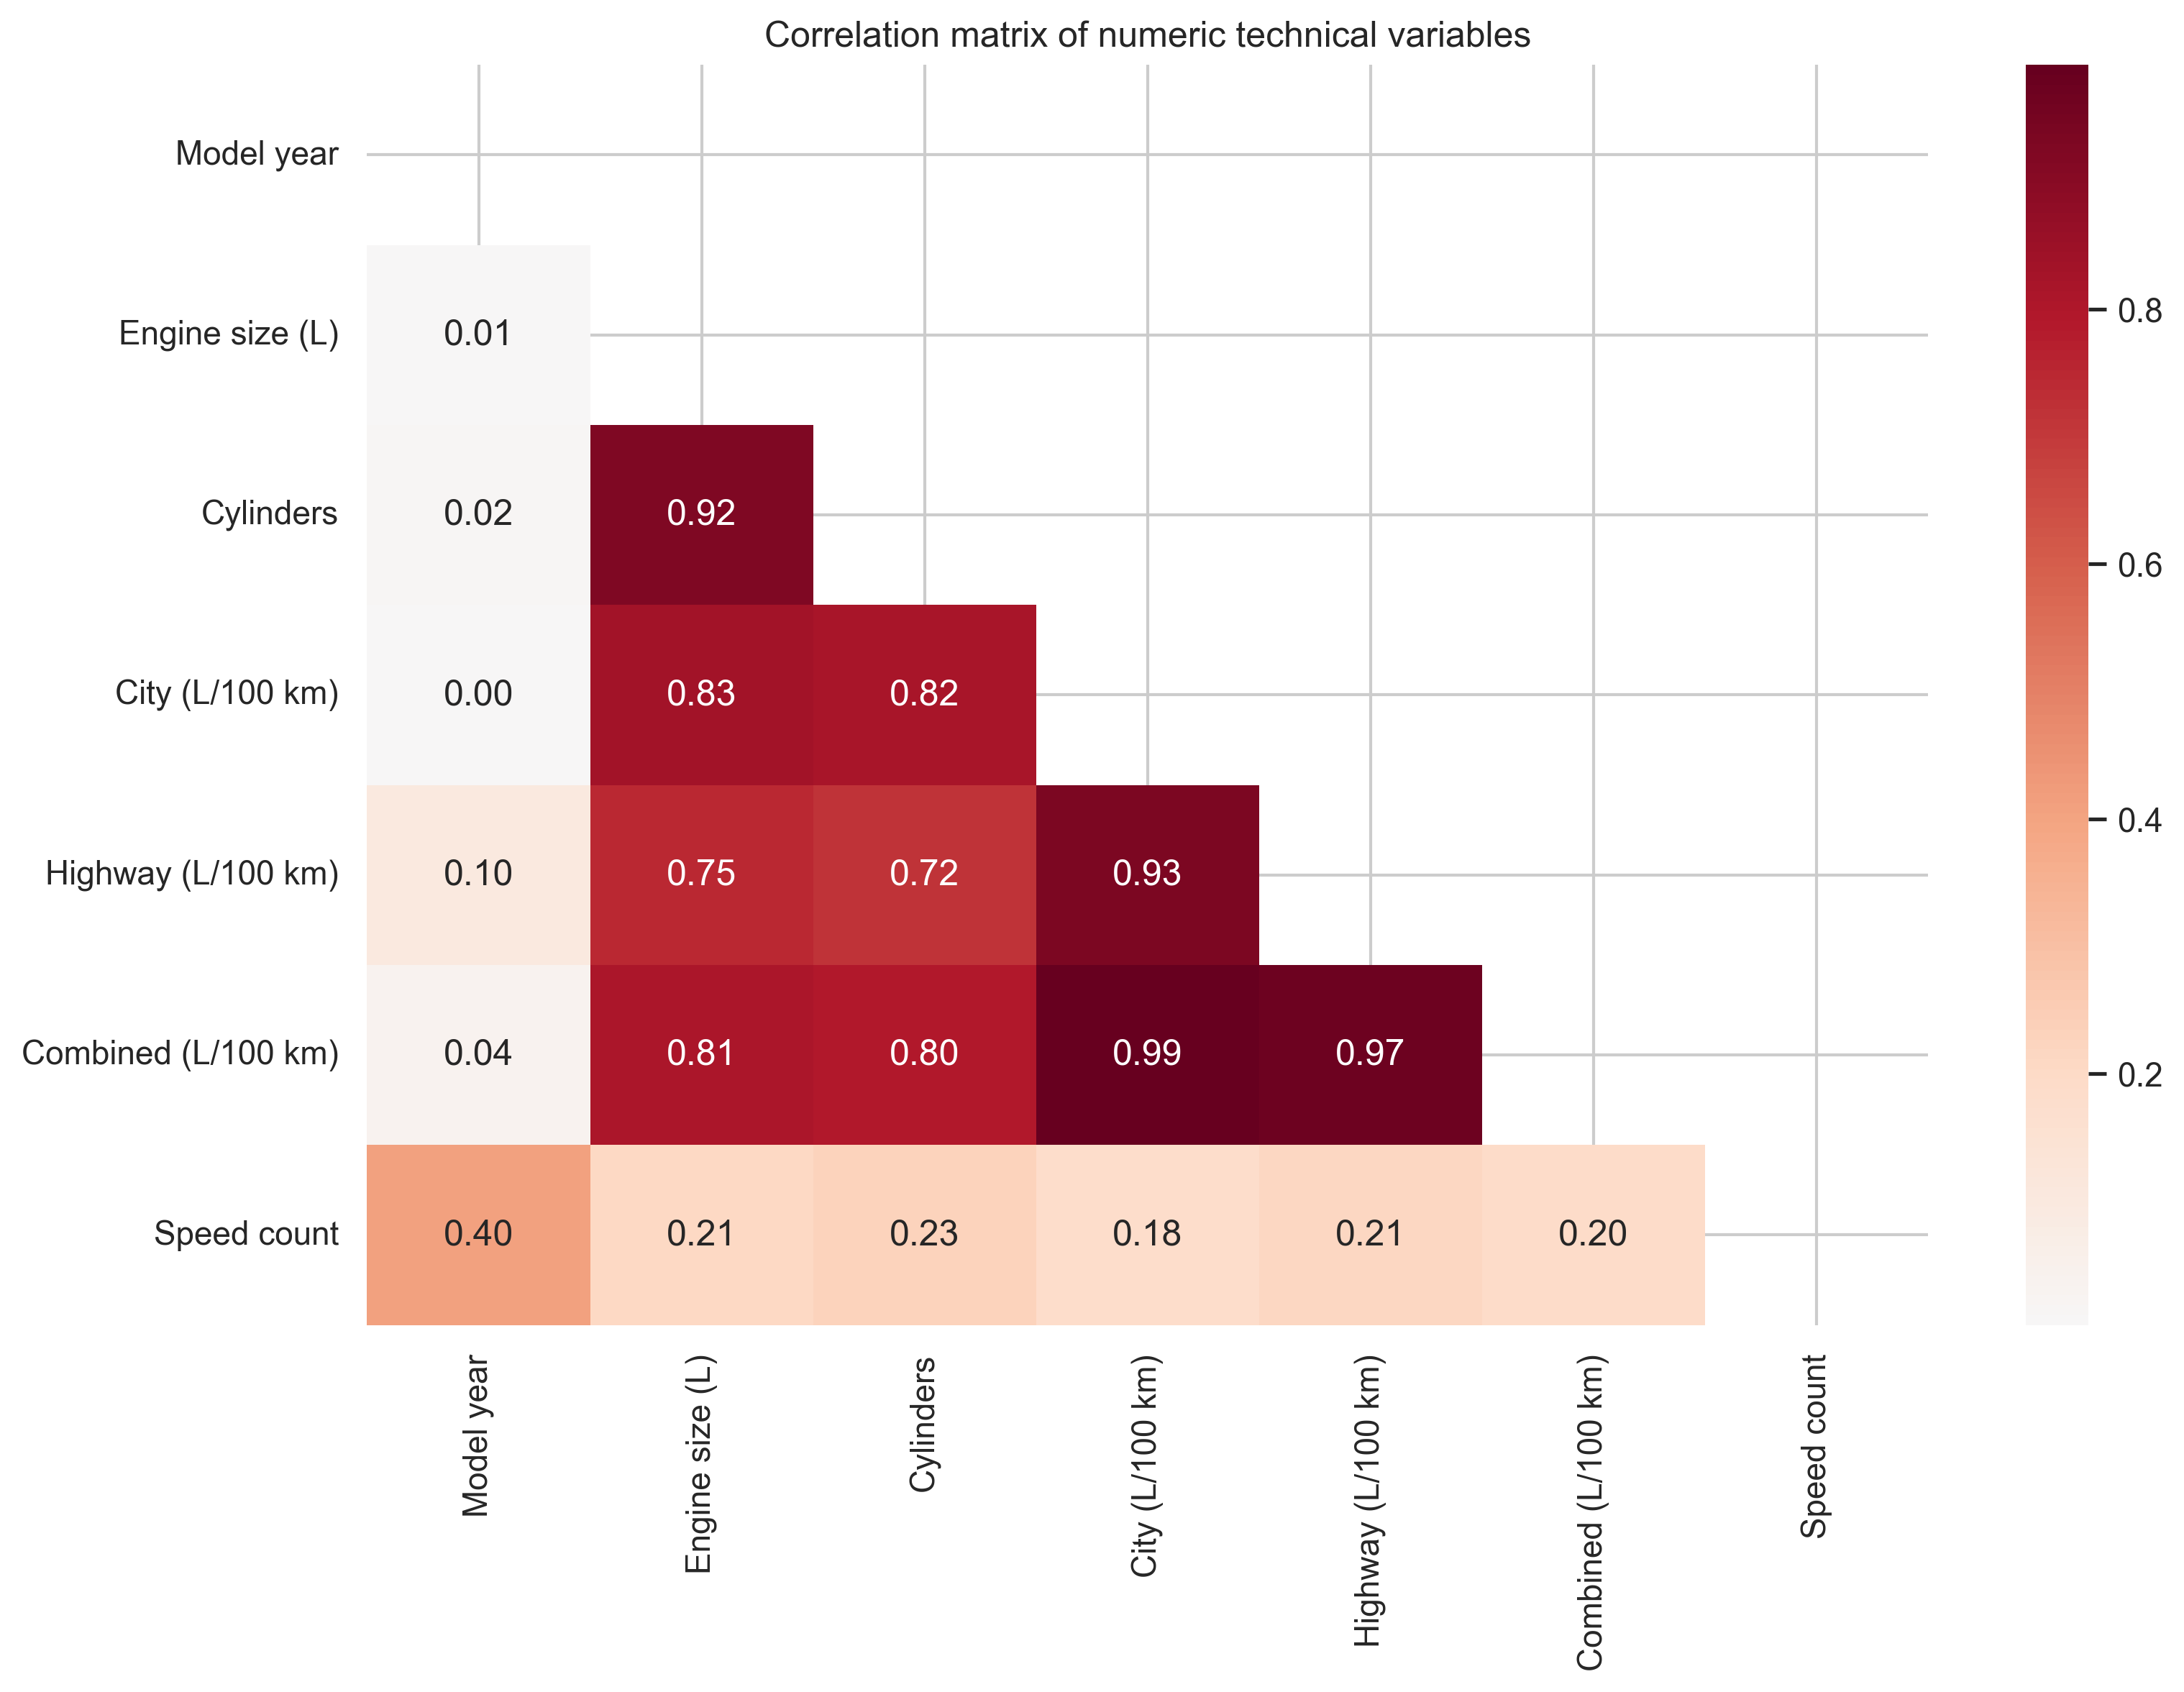


consumption_by_country.png


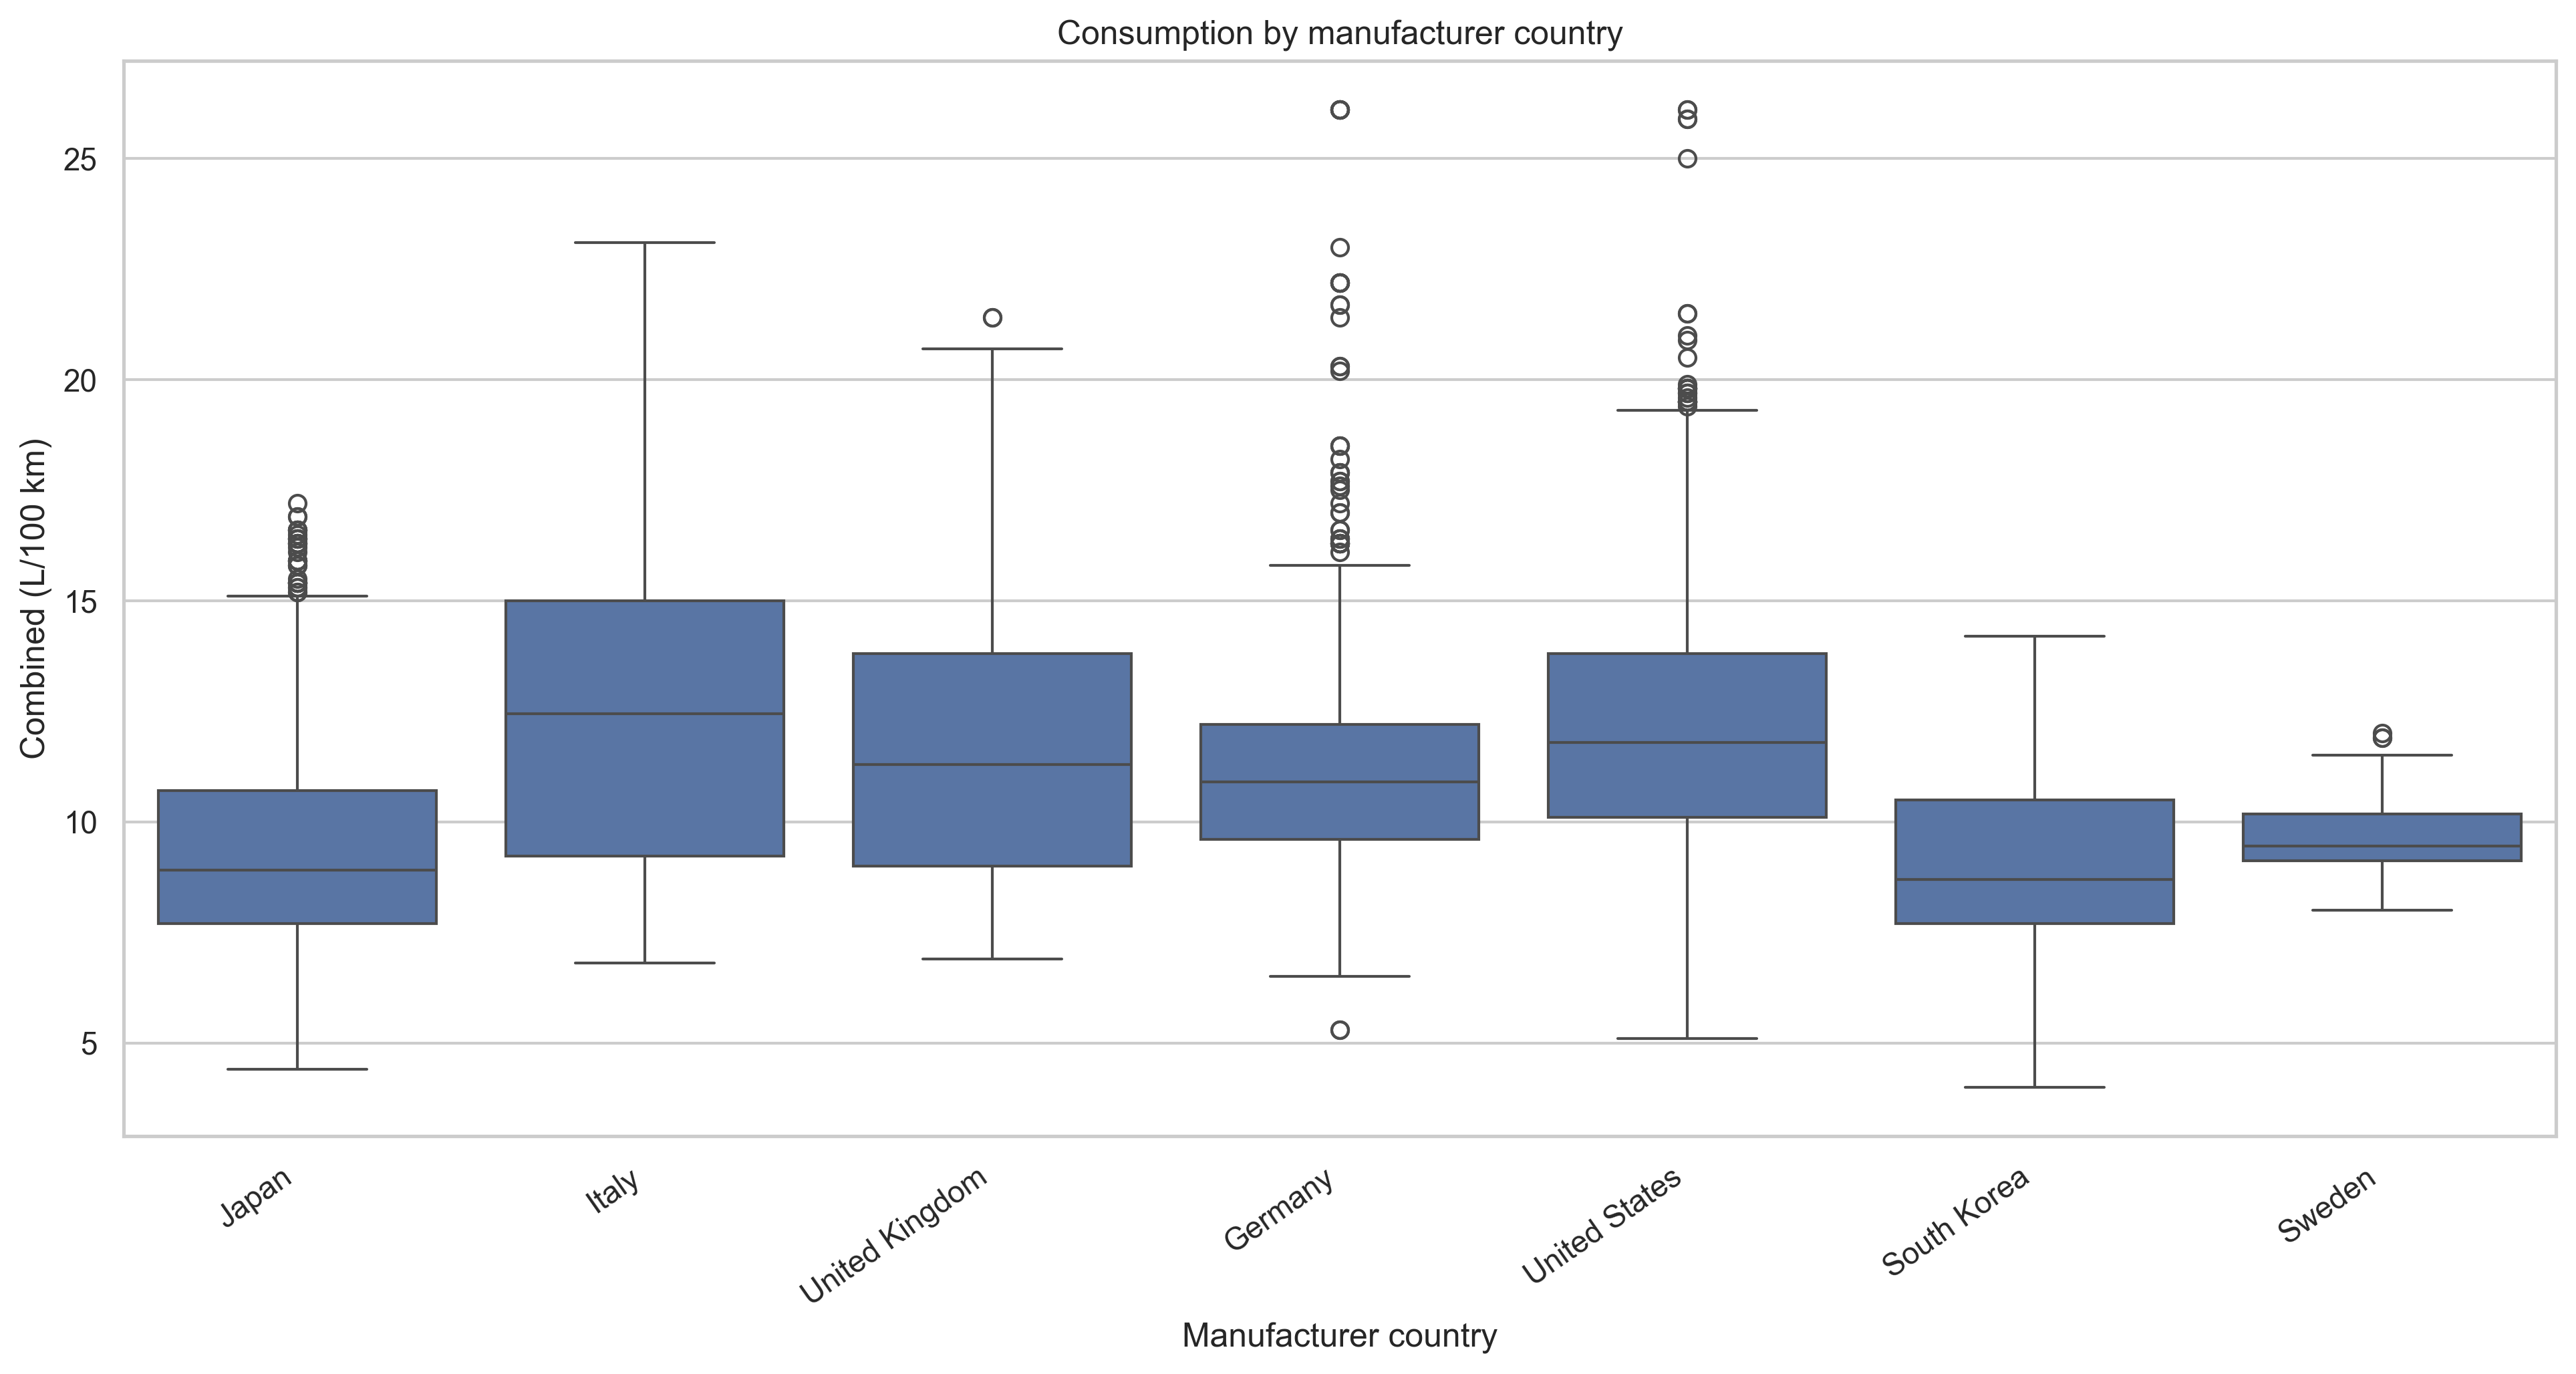


consumption_by_drivetrain.png


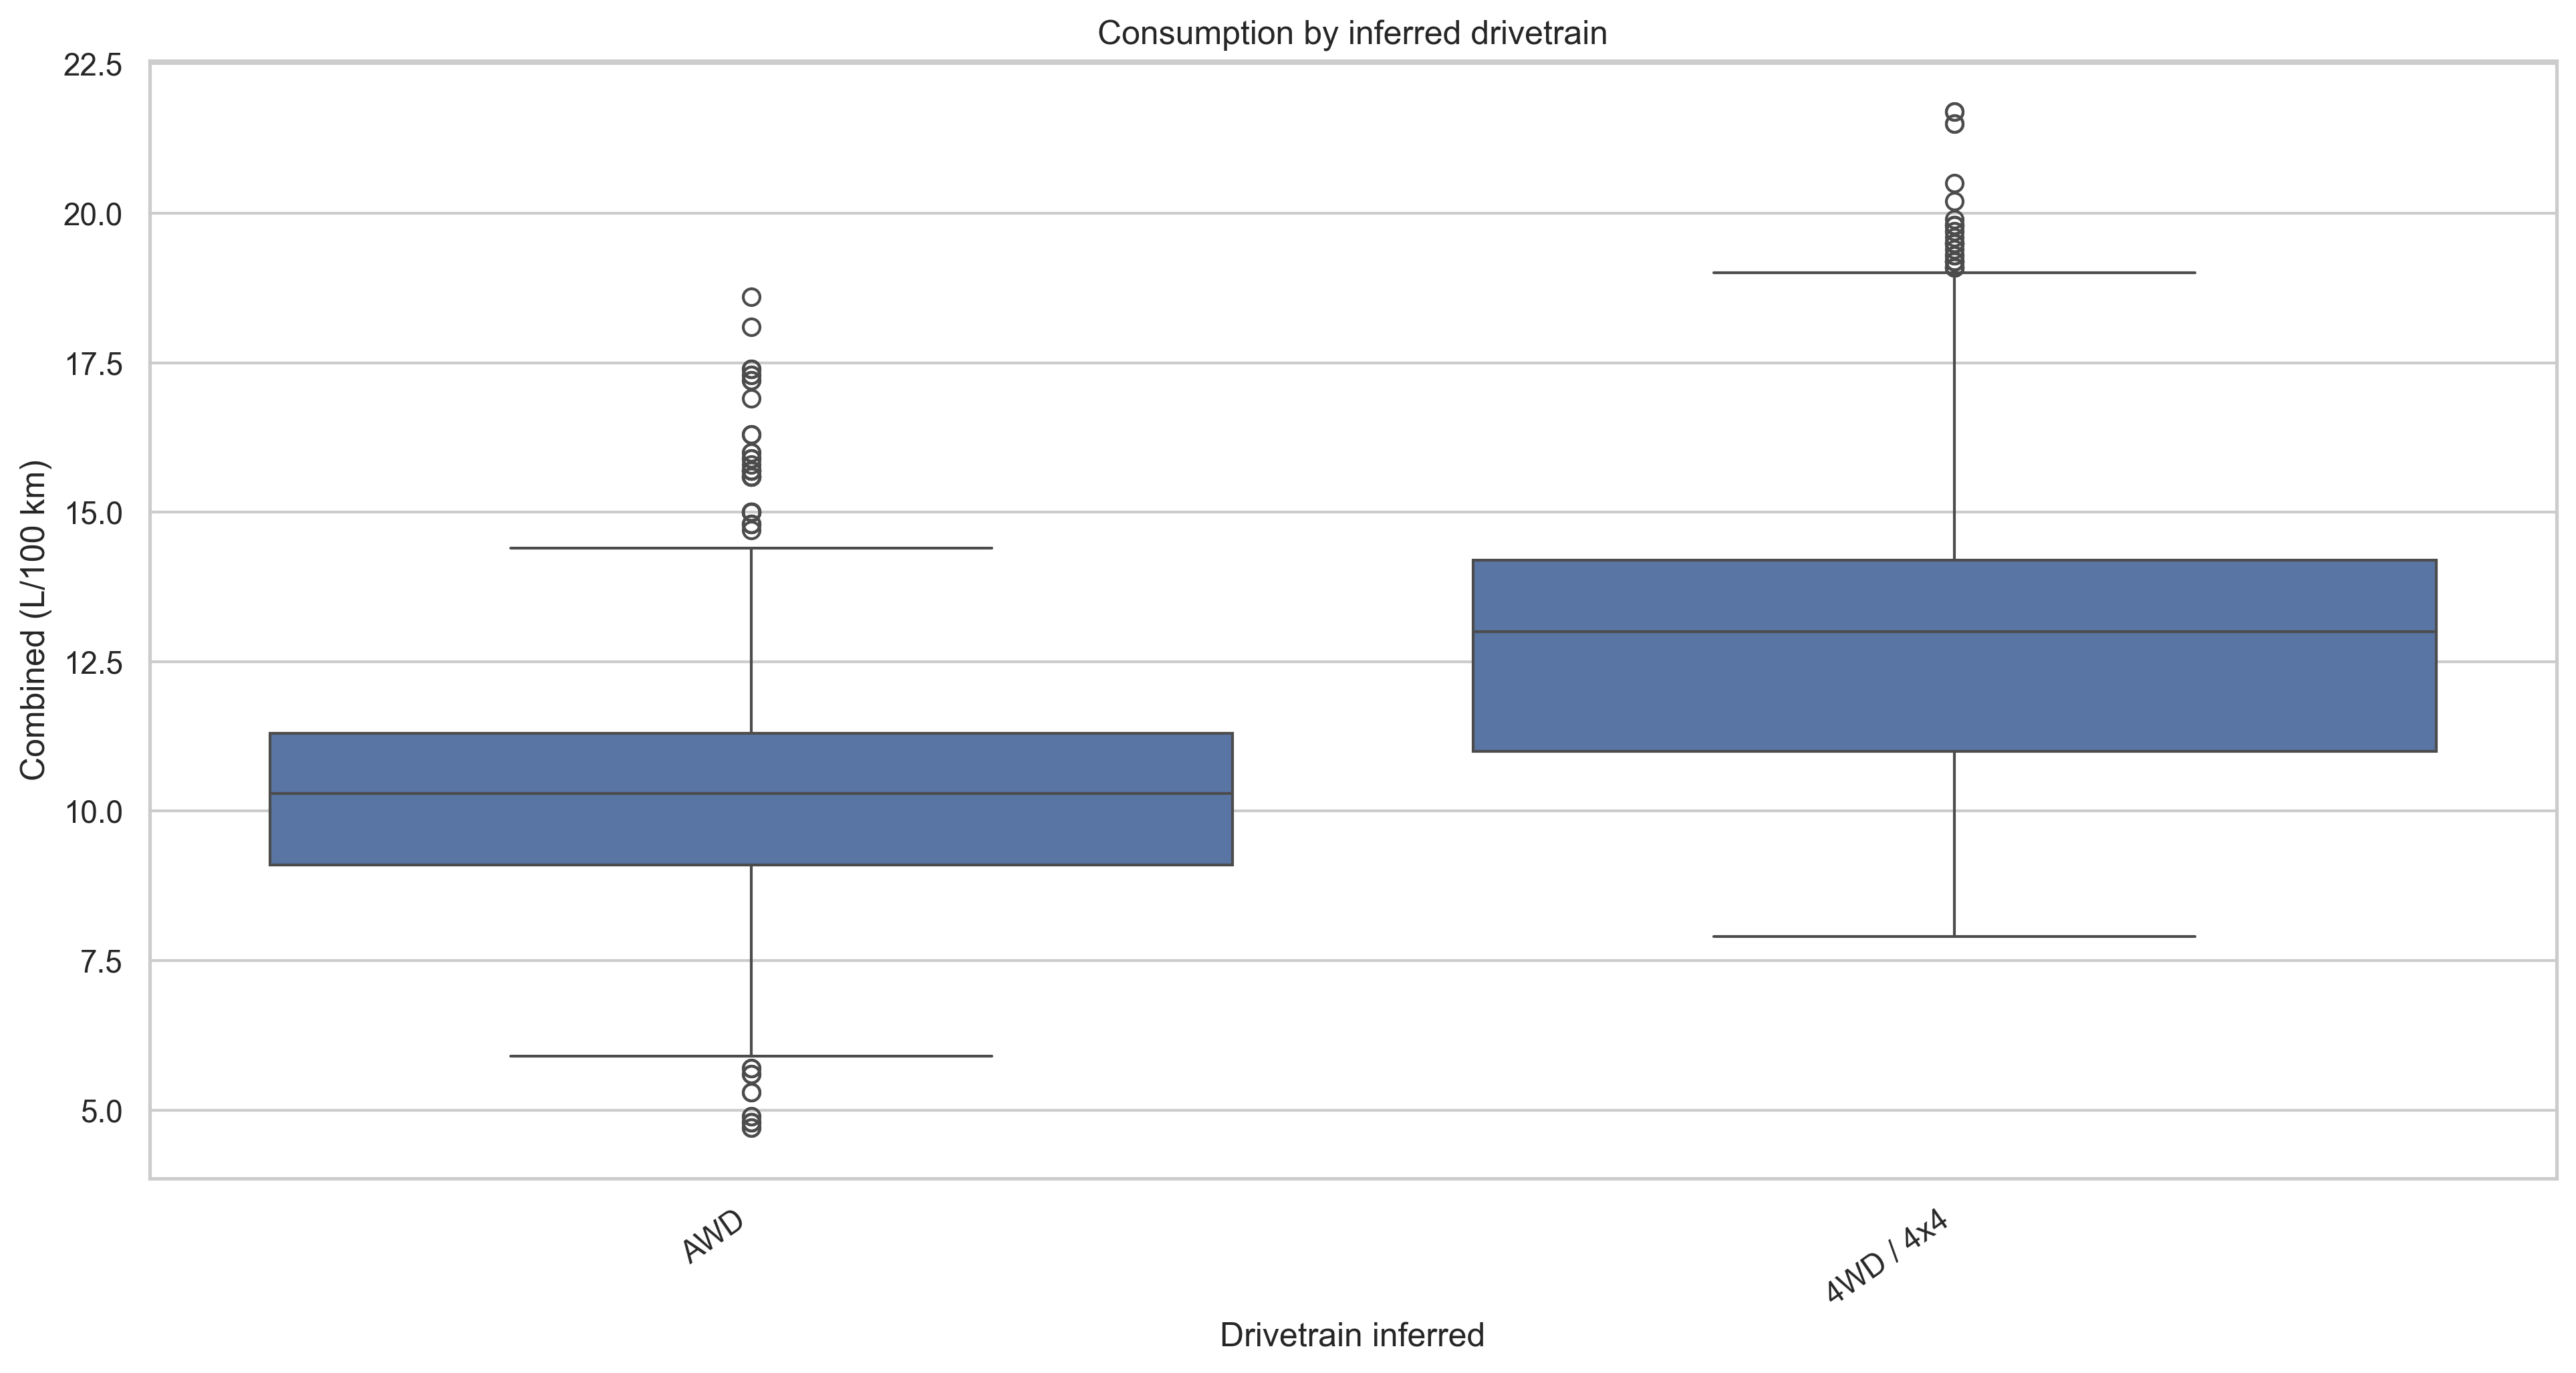


engine_size_vs_consumption.png


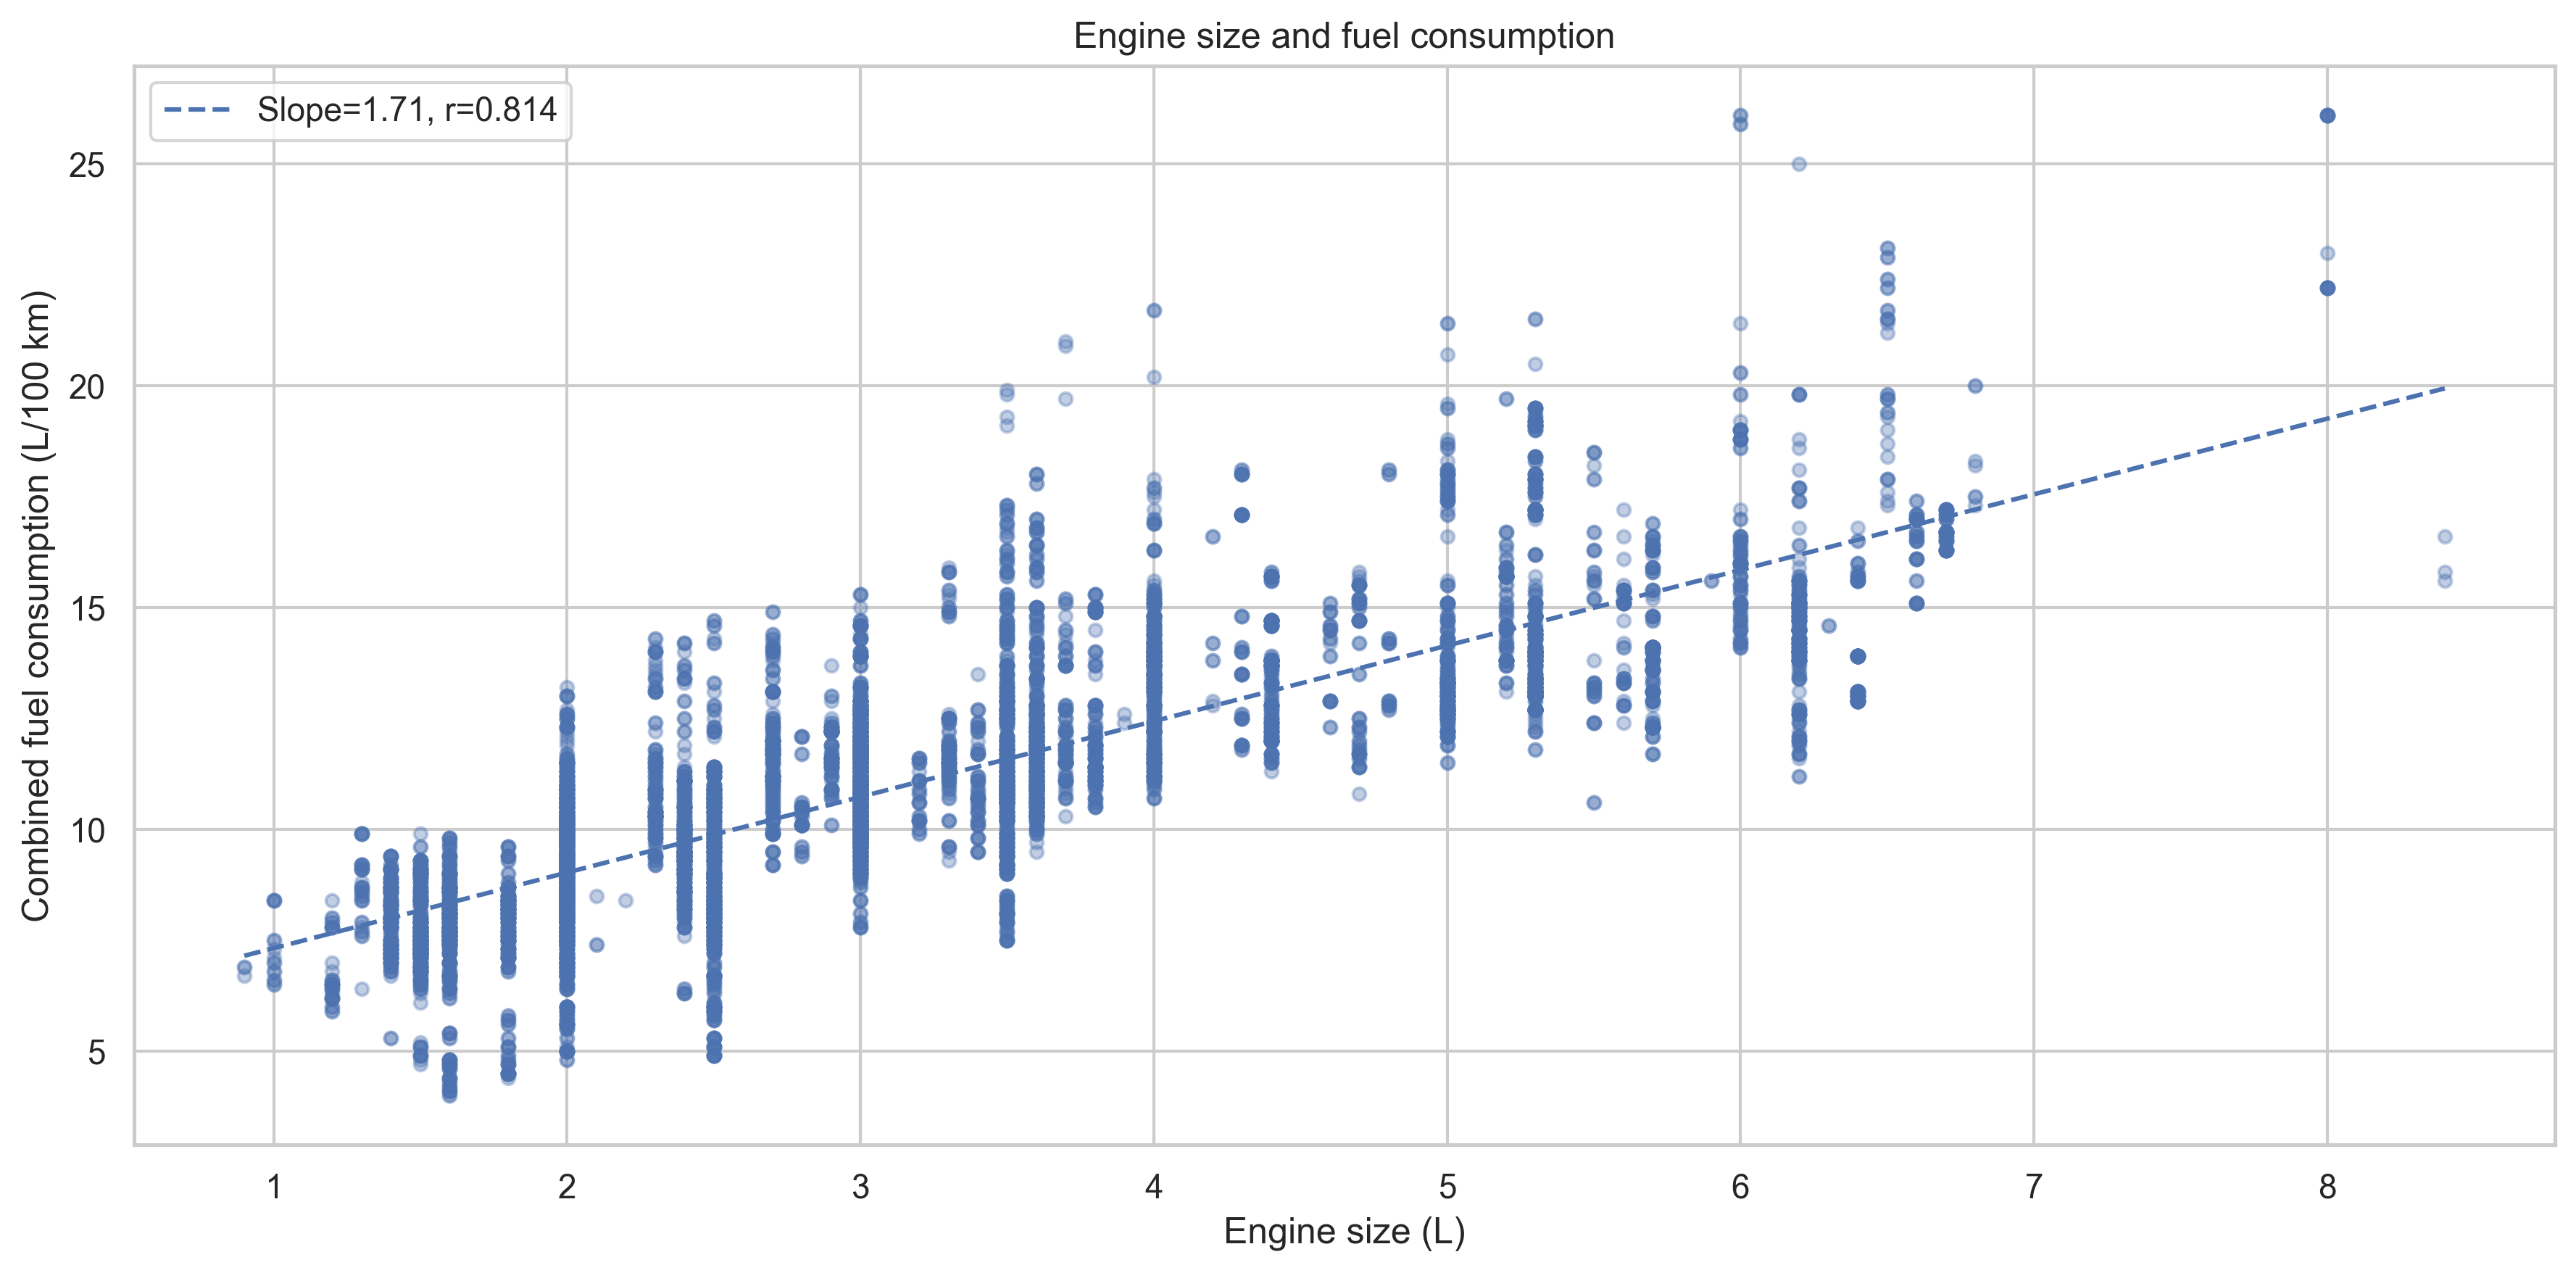


vehicle_class_distribution.png


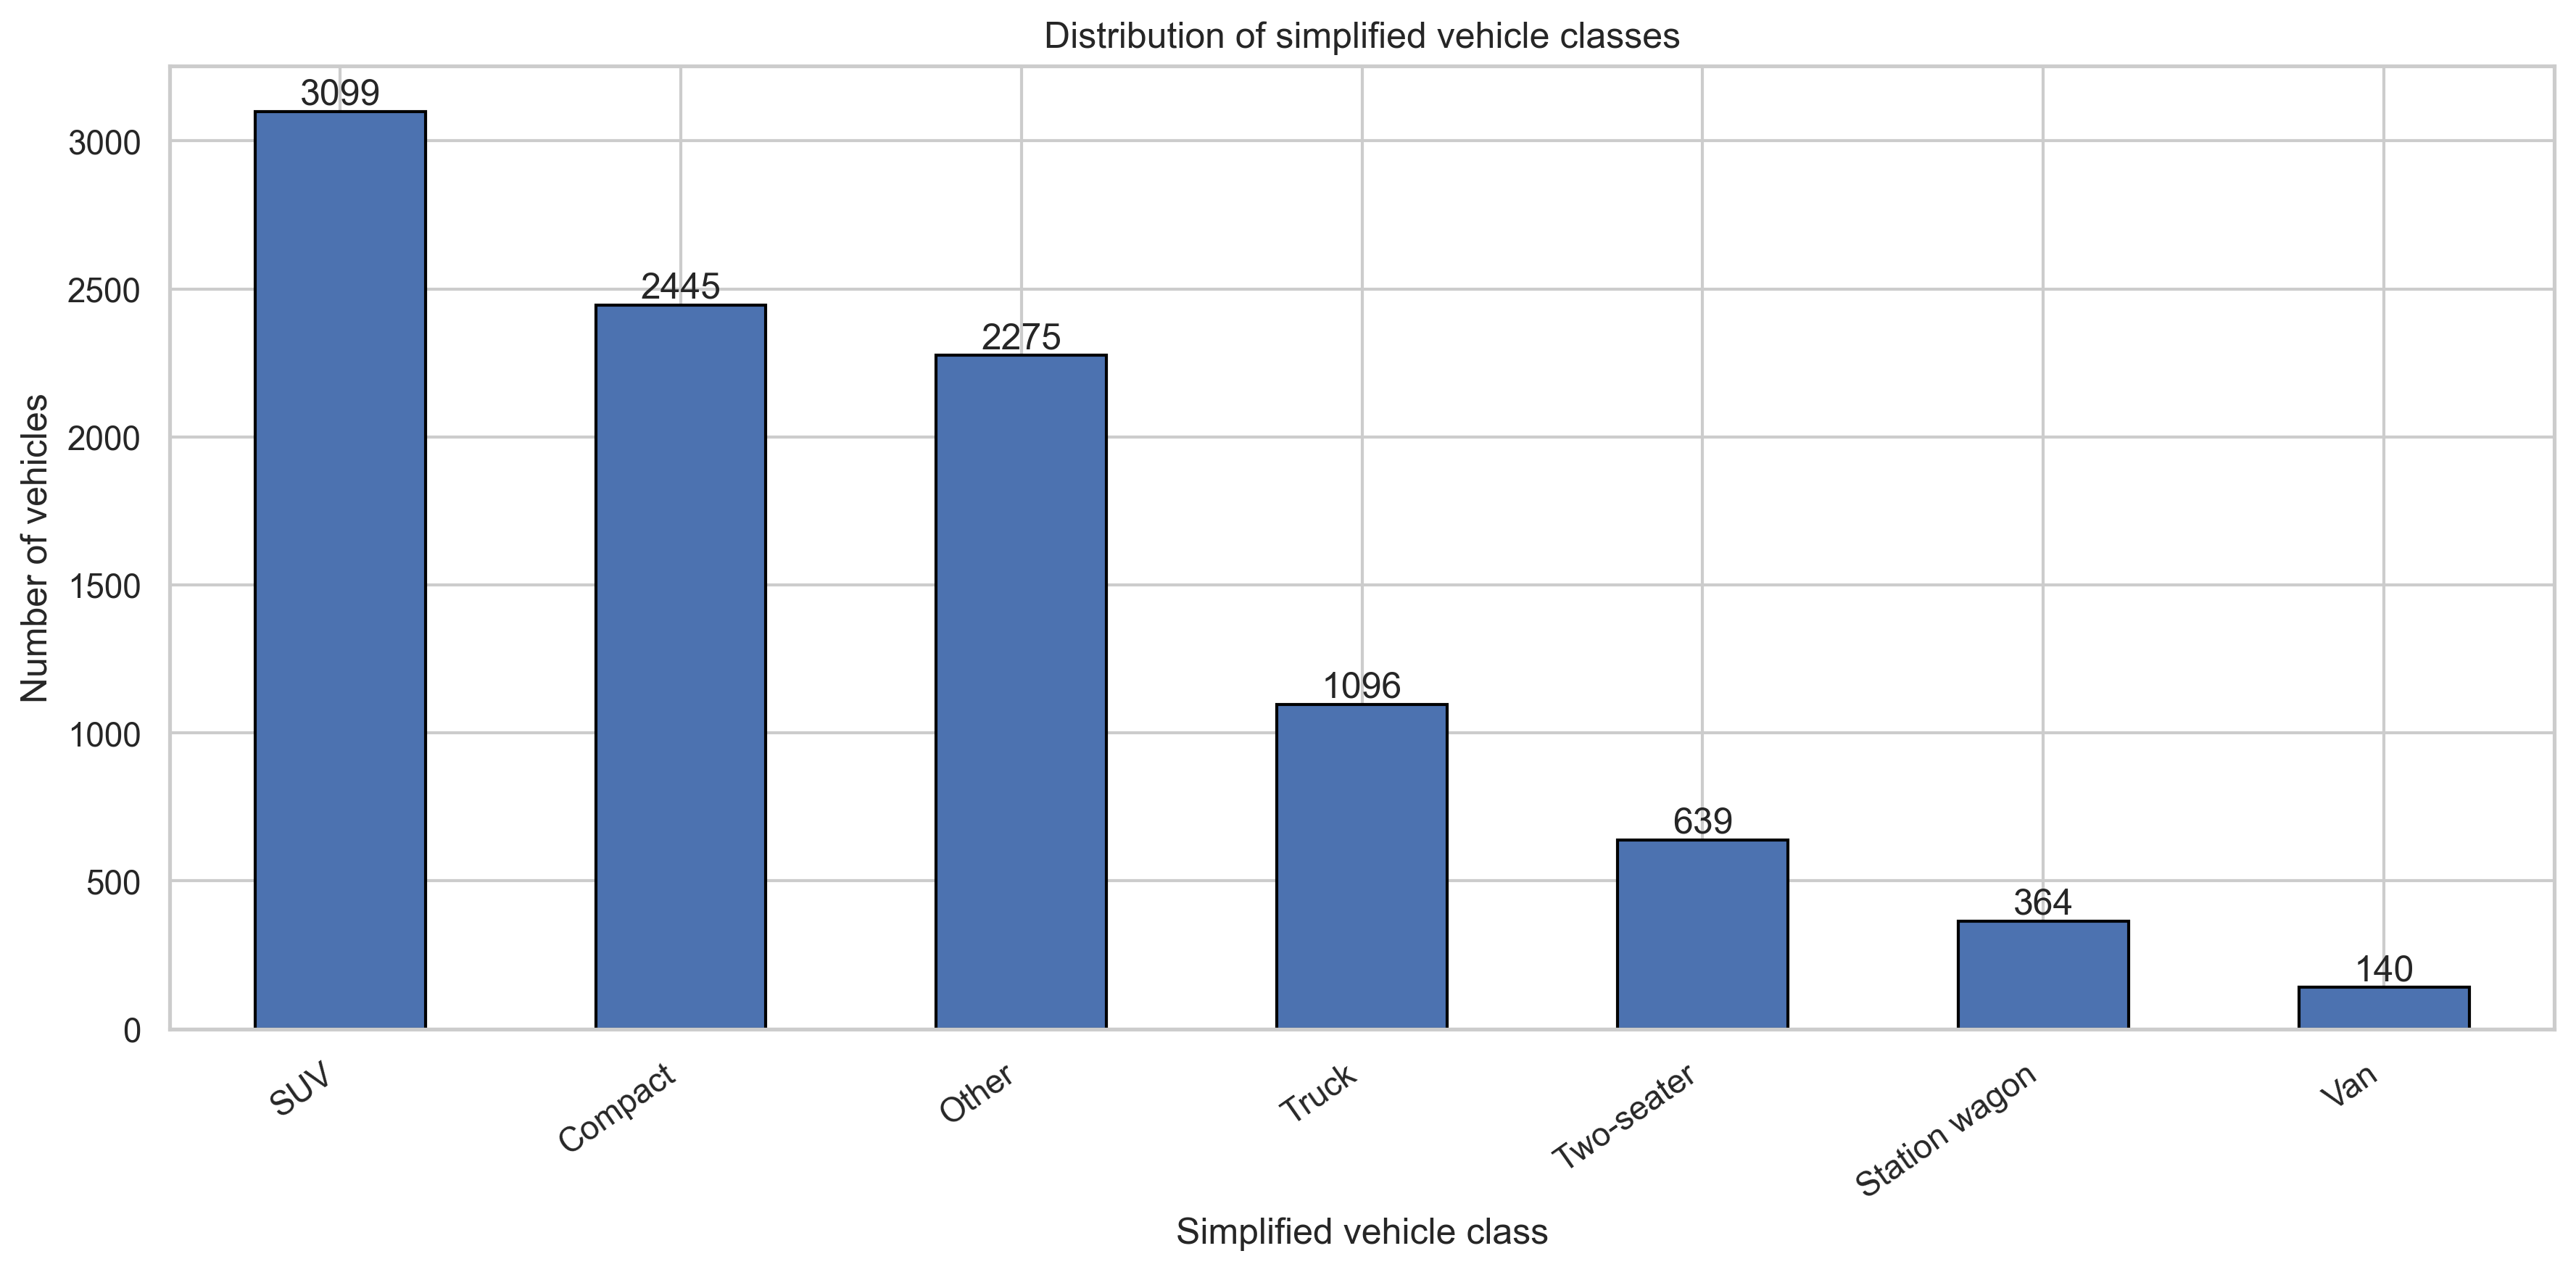

In [12]:
figure_files = [
    "consumption_distribution.png",
    "consumption_by_fuel.png",
    "numeric_correlation_matrix.png",
    "consumption_by_country.png",
    "consumption_by_drivetrain.png",
    "engine_size_vs_consumption.png",
    "vehicle_class_distribution.png",
]

for figure_name in figure_files:
    figure_path = FIGURES_DIR / figure_name

    if not figure_path.exists():
        raise FileNotFoundError(
            f"Expected figure not found: {figure_path}"
        )

    print(f"\n{figure_name}")
    display(Image(filename=str(figure_path)))


## 12. Verify all generated outputs

In [13]:
expected_tables = [
    quality_table_path,
    pairwise_table_path,
    global_table_path,
]

expected_figures = [
    FIGURES_DIR / figure_name
    for figure_name in figure_files
]

missing_outputs = [
    path
    for path in expected_tables + expected_figures
    if not path.exists()
]

if missing_outputs:
    raise AssertionError(
        "Some expected outputs were not generated:\n"
        + "\n".join(str(path) for path in missing_outputs)
    )

print("All expected tables and figures were generated successfully.")


All expected tables and figures were generated successfully.


## 13. Reload saved tables as a final integrity check

In [14]:
reloaded_quality = pd.read_csv(quality_table_path)
reloaded_pairwise = pd.read_csv(pairwise_table_path)
reloaded_global = pd.read_csv(global_table_path)

assert not reloaded_quality.empty
assert not reloaded_pairwise.empty
assert not reloaded_global.empty

print("Saved CSV files were reloaded successfully.")
print("The complete project pipeline test passed.")


Saved CSV files were reloaded successfully.
The complete project pipeline test passed.
